# Week 1 Internship Log - Day 1 & Day 2

## Project Setup and Objective
I started this project by setting up the Git repository and organizing the notebook structure so every step is traceable. The project uses a public grievance dataset (NYC 311 service requests) as a realistic civic feedback source.

My goal for the first two days was to build a solid base for NLP work by understanding the raw data and preparing it for text preprocessing. This included loading data safely, checking schema quality, identifying target columns, and documenting data issues before model-related work.

## What I Worked On (Day 1)
1. Initialized the project workspace and repository.
2. Installed all core libraries needed for data handling, visualization, and NLP.
3. Downloaded the dataset and verified file integrity.
4. Implemented a memory-aware loading strategy using sampling because the full file size is very large.
5. Explored metadata files and data dictionary resources to understand column meaning.
6. Performed first-level structural analysis: shape, datatypes, memory profile, and preview samples.

## What I Worked On (Day 2)
1. Identified text-oriented and label-oriented columns for downstream classification.
2. Performed a detailed missing-value audit.
3. Visualized missingness patterns to detect potential bias before preprocessing.
4. Cleaned rows missing critical fields (`category`, `text`).
5. Prepared and validated text preprocessing flow (including normalization and cleanup checks).
6. Computed foundational text statistics like character length and word count.

## What I Specifically Explored / Searched During the Work
- Which files are part of the dataset package and what each file is used for.
- How large-file CSV ingestion should be handled on limited RAM systems.
- Which columns are most suitable as complaint text vs target label.
- How missing values are distributed across columns and whether they are random or patterned.
- Whether preprocessing output preserves complaint meaning while removing noise.
- Whether text-length distribution is reasonable for training and feature engineering.

In [1]:
# Install required packages
!pip install kagglehub pandas numpy matplotlib seaborn nltk spacy wordcloud scikit-learn -q

In [2]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import os

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment setup is complete.")
print(f"Run timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Core Python libraries loaded successfully.")

Environment setup is complete.
Run timestamp: 2026-03-13 05:56:48
Core Python libraries loaded successfully.


In [3]:
# Download dataset using kagglehub
import kagglehub

print("Starting dataset download: NYC 311 Service Requests")
print("This may take a few minutes depending on internet speed.\n")

# Download latest version
path = kagglehub.dataset_download("new-york-city/ny-311-service-requests")

print("Dataset download finished successfully.")
print(f"Local dataset path: {path}")

Starting dataset download: NYC 311 Service Requests
This may take a few minutes depending on internet speed.



100%|██████████| 3.24G/3.24G [00:29<00:00, 118MB/s] 

Extracting files...


Dataset download finished successfully.
Local dataset path: /root/.cache/kagglehub/datasets/new-york-city/ny-311-service-requests/versions/53


In [4]:
# List files in the dataset
import os

print("Files available in the dataset directory:")
for file in os.listdir(path):
    file_path = os.path.join(path, file)
    file_size = os.path.getsize(file_path) / (1024 * 1024)  # Size in MB
    print(f"- {file} ({file_size:.2f} MB)")

Files available in the dataset directory:
- socrata_metadata_311-service-requests-from-2010-to-present.json (0.06 MB)
- 311_SR_Data_Dictionary_2018.xlsx (0.20 MB)
- socrata_metadata_311-web-content-services.json (0.03 MB)
- 311-service-requests-from-2010-to-present.csv (14007.02 MB)
- 311-web-content-services.csv (2079.55 MB)


In [5]:
# Comprehensive Data Loading from NYC 311 Dataset
# Dataset contains 5 files with different purposes

import json

print("="*80)
print("NYC 311 SERVICE REQUESTS - DATA LOADING")
print("="*80)

# Define all available files in the dataset
dataset_files = {
    '311-service-requests-from-2010-to-present.csv': 'Main dataset (14+ GB)',
    '311-web-content-services.csv': 'Web content services (2+ GB)',
    '311_SR_Data_Dictionary_2018.xlsx': 'Data dictionary/metadata',
    'socrata_metadata_311-service-requests-from-2010-to-present.json': 'Metadata JSON',
    'socrata_metadata_311-web-content-services.json': 'Web services metadata JSON'
}

# Verify which files are available
print("\n[INFO] Available Files in Dataset:")
print("-"*80)
available_files = []
for file_name in os.listdir(path):
    file_path = os.path.join(path, file_name)
    if os.path.isfile(file_path):
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # Size in MB
        available_files.append(file_name)
        description = dataset_files.get(file_name, 'Unknown file')
        print(f"[FOUND] {file_name}")
        print(f"  Size: {file_size:.2f} MB")
        print(f"  Description: {description}")
        print()

# Load metadata files for better understanding
print("\n[INFO] Loading Metadata Files...")
print("-"*80)

# Load data dictionary if available
data_dict_file = os.path.join(path, '311_SR_Data_Dictionary_2018.xlsx')
if os.path.exists(data_dict_file):
    try:
        import openpyxl
        print("[FOUND] Data Dictionary found: 311_SR_Data_Dictionary_2018.xlsx")
        print("  Use: pd.read_excel(data_dict_file) to view column descriptions")
    except ImportError:
        print("[WARNING] openpyxl not installed. Install with: pip install openpyxl")
else:
    print("[INFO] Data dictionary not found")

# Load JSON metadata
metadata_file = os.path.join(path, 'socrata_metadata_311-service-requests-from-2010-to-present.json')
if os.path.exists(metadata_file):
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    print(f"\n[SUCCESS] Metadata loaded from JSON")
    if 'columns' in metadata:
        print(f"  Dataset has {len(metadata['columns'])} documented columns")
    if 'description' in metadata:
        print(f"  Description: {metadata['description'][:100]}...")
else:
    print("[INFO] Metadata JSON not found")

# Load the main dataset (with smart sampling for development)
print("\n"+"="*80)
print("LOADING MAIN DATASET")
print("="*80)

# Choose which CSV file to load
main_csv_files = [
    '311-service-requests-from-2010-to-present.csv',
    '311-service-requests.csv'  # Alternative name
]

csv_file = None
for filename in main_csv_files:
    potential_path = os.path.join(path, filename)
    if os.path.exists(potential_path):
        csv_file = potential_path
        print(f"\n[FOUND] Main dataset: {filename}")
        file_size_gb = os.path.getsize(csv_file) / (1024 * 1024 * 1024)
        print(f"  File size: {file_size_gb:.2f} GB")
        break

if csv_file is None:
    raise FileNotFoundError("Main CSV file not found in dataset directory!")

# Smart loading strategy based on file size
print("\n[INFO] Loading Strategy:")
print("-"*80)

# For development: load a sample
# For production: load full dataset or use chunking
SAMPLE_SIZE = 50000  # Adjust based on your RAM (4GB RAM = 50k rows, 8GB RAM = 100k rows)

print(f"Loading first {SAMPLE_SIZE:,} rows for development")
print("[TIP] Increase SAMPLE_SIZE for more data or remove 'nrows' for full dataset")
print("[WARNING] Full dataset (~14GB) requires significant RAM (32GB+ recommended)")
print()

# Load data with progress indication
print("[PROCESSING] Reading CSV file...")
df_raw = pd.read_csv(
    csv_file, 
    nrows=SAMPLE_SIZE,
    low_memory=False,
    encoding='utf-8',
    on_bad_lines='skip'  # Skip problematic rows
)

print("\n"+"="*80)
print("[SUCCESS] DATA LOADING COMPLETE")
print("="*80)
print(f"\nDataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory Usage: {df_raw.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
print(f"Date Range: {df_raw['Created Date'].min() if 'Created Date' in df_raw.columns else 'N/A'} to {df_raw['Created Date'].max() if 'Created Date' in df_raw.columns else 'N/A'}")
print()

# Display first few rows
print("[PREVIEW] First 3 rows:")
print("-"*80)
df_raw.head(3)

NYC 311 SERVICE REQUESTS - DATA LOADING

[INFO] Available Files in Dataset:
--------------------------------------------------------------------------------
[FOUND] socrata_metadata_311-service-requests-from-2010-to-present.json
  Size: 0.06 MB
  Description: Metadata JSON

[FOUND] 311_SR_Data_Dictionary_2018.xlsx
  Size: 0.20 MB
  Description: Data dictionary/metadata

[FOUND] socrata_metadata_311-web-content-services.json
  Size: 0.03 MB
  Description: Web services metadata JSON

[FOUND] 311-service-requests-from-2010-to-present.csv
  Size: 14007.02 MB
  Description: Main dataset (14+ GB)

[FOUND] 311-web-content-services.csv
  Size: 2079.55 MB
  Description: Web content services (2+ GB)


[INFO] Loading Metadata Files...
--------------------------------------------------------------------------------
[FOUND] Data Dictionary found: 311_SR_Data_Dictionary_2018.xlsx
  Use: pd.read_excel(data_dict_file) to view column descriptions

[SUCCESS] Metadata loaded from JSON
  Dataset has 46 do

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,...,NaN,NaN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,...,NaN,NaN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,...,NaN,NaN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN


In [6]:
# Display detailed preview of the dataset
print("="*80)
print("DETAILED DATASET PREVIEW")
print("="*80)

print("\n[INFO] First 5 rows:")
print("-"*80)
display(df_raw.head())

print("\n[INFO] Last 5 rows:")
print("-"*80)
display(df_raw.tail())

print("\n[INFO] Random Sample (5 rows):")
print("-"*80)
display(df_raw.sample(5, random_state=RANDOM_SEED))

DETAILED DATASET PREVIEW

[INFO] First 5 rows:
--------------------------------------------------------------------------------


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,...,NaN,NaN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,...,NaN,NaN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,...,NaN,NaN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN
3,45052046,2019-12-01T01:58:23.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11358.0,42-41 159 STREET,...,NaN,NaN,40.759994,-73.806856,"{'longitude': '-73.80685560533585', 'latitude'...",NaN,NaN,NaN,NaN,NaN
4,45054999,2019-12-01T01:58:07.000,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11426.0,88-49 237 STREET,...,NaN,NaN,40.729499,-73.729998,"{'longitude': '-73.72999847973517', 'latitude'...",NaN,NaN,NaN,NaN,NaN



[INFO] Last 5 rows:
--------------------------------------------------------------------------------


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
49995,44994382,2019-11-22T16:58:39.000,NaN,HPD,Department of Housing Preservation and Develop...,ELECTRIC,OUTLET/SWITCH,RESIDENTIAL BUILDING,11224.0,2970 WEST 24 STREET,...,NaN,NaN,40.574134,-73.990810,"{'longitude': '-73.99081007810318', 'latitude'...",18184.0,21.0,2.0,45.0,35.0
49996,44997024,2019-11-22T16:58:37.000,NaN,TLC,Taxi and Limousine Commission,Green Taxi Complaint,Driver Complaint - Passenger,NaN,10035.0,EAST 125 STREET,...,NaN,NaN,40.805057,-73.939034,"{'longitude': '-73.93903422529588', 'latitude'...",13093.0,7.0,4.0,36.0,16.0
49997,44996473,2019-11-22T16:58:33.000,NaN,HPD,Department of Housing Preservation and Develop...,ELECTRIC,LIGHTING,RESIDENTIAL BUILDING,10010.0,143 EAST 23 STREET,...,NaN,NaN,40.739358,-73.984360,"{'longitude': '-73.98436040389754', 'latitude'...",12073.0,71.0,4.0,50.0,7.0
49998,44994608,2019-11-22T16:58:26.000,2019-11-25T09:15:49.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,RESIDENTIAL BUILDING,10451.0,341 EAST 146 STREET,...,NaN,NaN,40.815147,-73.920994,"{'longitude': '-73.92099403182274', 'latitude'...",10929.0,49.0,5.0,35.0,23.0
49999,44995640,2019-11-22T16:58:00.000,2019-11-22T21:00:00.000,DOT,Department of Transportation,Traffic Signal Condition,Veh Signal Lamp,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



[INFO] Random Sample (5 rows):
--------------------------------------------------------------------------------


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
33553,44999135,2019-11-23T23:13:27.000,2019-11-24T13:50:41.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10452.0,1460 MACOMBS ROAD,...,NaN,NaN,40.841519,-73.917735,"{'longitude': '-73.91773529835133', 'latitude'...",10930.0,50.0,5.0,42.0,27.0
9427,45037079,2019-11-28T23:26:22.000,2019-11-30T00:52:35.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11106.0,35-15 32 STREET,...,NaN,NaN,40.757364,-73.928007,"{'longitude': '-73.92800736052247', 'latitude'...",16863.0,39.0,3.0,33.0,72.0
199,45052697,2019-12-01T00:47:45.000,2019-12-01T01:05:25.000,NYPD,New York City Police Department,Noise - Residential,Loud Talking,Residential Building/House,10310.0,97 BODINE STREET,...,NaN,NaN,40.636161,-74.125478,"{'longitude': '-74.12547818749105', 'latitude'...",NaN,NaN,NaN,NaN,NaN
12447,45037676,2019-11-28T07:18:29.000,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,RESIDENTIAL BUILDING,10456.0,1259 CLAY AVENUE,...,NaN,NaN,40.833578,-73.909940,"{'longitude': '-73.90993953695556', 'latitude'...",10934.0,50.0,5.0,42.0,27.0
39489,45003925,2019-11-22T19:19:10.000,2019-11-22T19:19:10.000,DOB,Department of Buildings,Elevator,Elevator - Single Device On Property/No Altern...,NaN,10034.0,221 SHERMAN AVENUE,...,NaN,NaN,40.865685,-73.920276,"{'longitude': '-73.92027598053774', 'latitude'...",13092.0,47.0,4.0,39.0,22.0


In [7]:
# Comprehensive dataset information
print("="*80)
print("DATASET STRUCTURE & INFORMATION")
print("="*80)

print("\n[INFO] Dataset Info:")
print("-"*80)
df_raw.info(verbose=True, show_counts=True)

print("\n\n[INFO] Dataset Dimensions:")
print("-"*80)
print(f"Total Rows: {df_raw.shape[0]:,}")
print(f"Total Columns: {df_raw.shape[1]:,}")
print(f"Total Cells: {df_raw.shape[0] * df_raw.shape[1]:,}")

print("\n\n[INFO] Memory Usage by Column (Top 10):")
print("-"*80)
memory_usage = df_raw.memory_usage(deep=True).sort_values(ascending=False)
for col, mem in memory_usage.head(10).items():
    print(f"{col:30s}: {mem / (1024*1024):>8.2f} MB")
    
print(f"\nTotal Memory: {memory_usage.sum() / (1024*1024):.2f} MB")

print("\n\n[INFO] Data Types Distribution:")
print("-"*80)
dtype_counts = df_raw.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"{str(dtype):20s}: {count:3d} columns")


DATASET STRUCTURE & INFORMATION

[INFO] Dataset Info:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      50000 non-null  int64  
 1   Created Date                    50000 non-null  object 
 2   Closed Date                     37953 non-null  object 
 3   Agency                          50000 non-null  object 
 4   Agency Name                     50000 non-null  object 
 5   Complaint Type                  50000 non-null  object 
 6   Descriptor                      48859 non-null  object 
 7   Location Type                   35682 non-null  object 
 8   Incident Zip                    48820 non-null  float64
 9   Incident Address                47516 non-null  object 
 10  Street Name        

In [8]:
# Identify potential text and label columns
print("[TARGET] Key Columns for NLP Task:\n")

# Text columns (descriptions)
text_columns = [col for col in df_raw.columns if 
                'description' in col.lower() or 
                'complaint' in col.lower() or
                'descriptor' in col.lower()]

print("[TEXT] Text Columns (for complaint descriptions):")
for col in text_columns:
    print(f"   - {col}")

# Label columns (categories/departments)
label_columns = [col for col in df_raw.columns if 
                 'type' in col.lower() or 
                 'category' in col.lower() or
                 'agency' in col.lower()]

print("\n[DEPT] Label Columns (for department classification):")
for col in label_columns:
    print(f"   - {col}")

[TARGET] Key Columns for NLP Task:

[TEXT] Text Columns (for complaint descriptions):
   - Complaint Type
   - Descriptor
   - Resolution Description

[DEPT] Label Columns (for department classification):
   - Agency
   - Agency Name
   - Complaint Type
   - Location Type
   - Address Type
   - Facility Type
   - Open Data Channel Type
   - Vehicle Type


MISSING VALUE ANALYSIS

[STATS] Columns with Missing Values: 36 out of 46 columns
Total missing values: 660,656
Missing value percentage: 28.72%

--------------------------------------------------------------------------------
Top 20 Columns by Missing Percentage:
--------------------------------------------------------------------------------


,Column,Missing_Count,Missing_Percentage,Data_Type
Due Date,Due Date,50000,100.00,float64
Bridge Highway Name,Bridge Highway Name,49995,99.99,object
Vehicle Type,Vehicle Type,49973,99.95,object
Taxi Company Borough,Taxi Company Borough,49953,99.91,object
Bridge Highway Direction,Bridge Highway Direction,49945,99.89,object
Road Ramp,Road Ramp,49946,99.89,object
Bridge Highway Segment,Bridge Highway Segment,49946,99.89,object
Taxi Pick Up Location,Taxi Pick Up Location,49015,98.03,object
Facility Type,Facility Type,48528,97.06,object
Address Type,Address Type,28749,57.50,object



[CHART] Visualization:


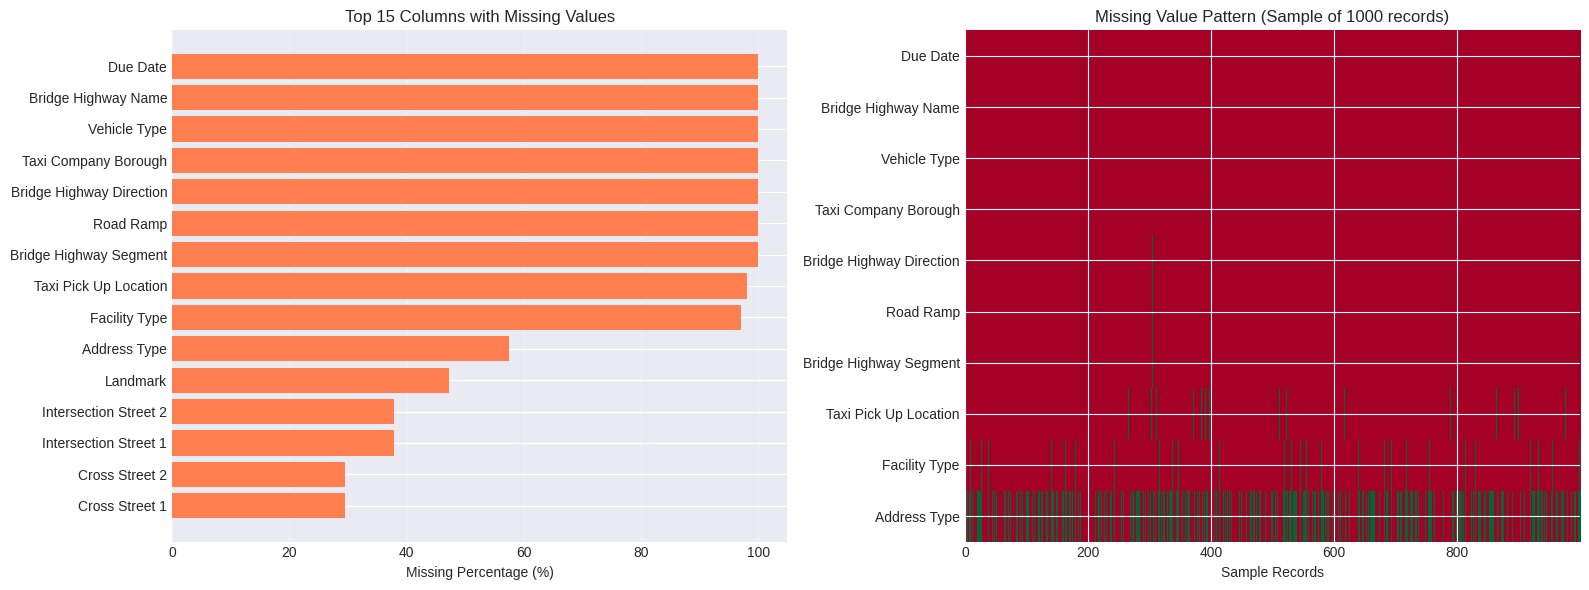

In [9]:
# Comprehensive missing value analysis
print("="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Data_Type': df_raw.dtypes
})

# Sort by missing percentage
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print(f"\n[STATS] Columns with Missing Values: {len(missing_data)} out of {len(df_raw.columns)} columns")
print(f"Total missing values: {df_raw.isnull().sum().sum():,}")
print(f"Missing value percentage: {(df_raw.isnull().sum().sum() / (len(df_raw) * len(df_raw.columns)) * 100):.2f}%")

print("\n" + "-"*80)
print("Top 20 Columns by Missing Percentage:")
print("-"*80)
display(missing_data.head(20))

# Visualize missing values
if len(missing_data) > 0:
    print("\n[CHART] Visualization:")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot for top 15 columns
    top_missing = missing_data.head(15)
    axes[0].barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='coral')
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Column'])
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Top 15 Columns with Missing Values')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Missing value heatmap (sample)
    if len(df_raw) > 1000:
        sample_df = df_raw.sample(min(1000, len(df_raw)))
    else:
        sample_df = df_raw
    
    # Select columns with missing values for heatmap
    cols_with_missing = missing_data.head(10)['Column'].tolist()
    if cols_with_missing:
        axes[1].imshow(sample_df[cols_with_missing].isnull().T, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
        axes[1].set_yticks(range(len(cols_with_missing)))
        axes[1].set_yticklabels(cols_with_missing)
        axes[1].set_xlabel('Sample Records')
        axes[1].set_title(f'Missing Value Pattern (Sample of {len(sample_df)} records)')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n[SUCCESS] No missing values found in the dataset!")


In [10]:
# Save checkpoint - raw data summary
checkpoint_summary = {
    'date': datetime.now().strftime('%Y-%m-%d'),
    'week': 1,
    'days': '1-2',
    'dataset_shape': df_raw.shape,
    'total_columns': len(df_raw.columns),
    'text_columns': text_columns,
    'label_columns': label_columns,
    'missing_data_summary': missing_data.to_dict()
}

print("[SAVE] Day 1-2 Checkpoint Saved")
print("[STATS] Ready to proceed with Days 3-4: Text Preprocessing")

[SAVE] Day 1-2 Checkpoint Saved
[STATS] Ready to proceed with Days 3-4: Text Preprocessing


## Day 1-2 Reflection
During these two days, I focused less on speed and more on correctness. The biggest practical challenge was dataset size, so I intentionally used sampling to keep analysis reproducible on normal hardware. I also made sure to inspect metadata instead of guessing column intent.

By the end of Day 2, I had a clean and well-understood working dataset with clear text/label columns and baseline text statistics. This created a reliable handoff point for deeper NLP tasks in the next phase.

In [11]:
# Download and load spaCy model
import sys
import subprocess

print("[DOWNLOAD] Downloading spaCy English model...")
subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])

import spacy
nlp = spacy.load('en_core_web_sm')

print("[SUCCESS] spaCy model loaded successfully!")

[DOWNLOAD] Downloading spaCy English model...
[SUCCESS] spaCy model loaded successfully!


In [14]:
# Prepare working dataframe with renamed columns for NLP task
print("[INFO] Preparing working dataframe...\n")

# Map raw columns to standardized names
df = df_raw[['Complaint Type', 'Descriptor', 'Agency']].copy()
df = df.rename(columns={
    'Complaint Type': 'category',
    'Descriptor': 'text',
    'Agency': 'agency'
})

print(f"Initial rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nCategory distribution (top 10):")
print(df['category'].value_counts().head(10))

[INFO] Preparing working dataframe...

Initial rows: 50,000
Columns: ['category', 'text', 'agency']

Category distribution (top 10):
category
Noise - Residential                  7556
HEAT/HOT WATER                       7361
Illegal Parking                      5307
Blocked Driveway                     4273
Street Condition                     1371
Water System                         1313
Noise - Commercial                   1120
Noise - Street/Sidewalk              1106
Missed Collection (All Materials)    1085
Noise                                 995
Name: count, dtype: int64


In [15]:
# Remove rows with missing values in critical columns
print("[CLEAN] Cleaning data...\n")

initial_rows = len(df)
df = df.dropna(subset=['category', 'text'])
removed_rows = initial_rows - len(df)

print(f"Removed {removed_rows:,} rows with missing values")
print(f"Remaining rows: {len(df):,}")

# Display sample
print("\n[INFO] Sample of data:")
df.head(10)

[CLEAN] Cleaning data...

Removed 1,141 rows with missing values
Remaining rows: 48,859

[INFO] Sample of data:


,category,text,agency
0,Street Condition,Pothole,DOT
1,Noise - Commercial,Loud Music/Party,NYPD
2,Noise - Residential,Loud Music/Party,NYPD
3,Noise - Residential,Loud Music/Party,NYPD
4,Illegal Parking,Commercial Overnight Parking,NYPD
5,Noise - Residential,Loud Music/Party,NYPD
6,Noise - Residential,Banging/Pounding,NYPD
7,Noise - Commercial,Loud Music/Party,NYPD
8,Taxi Complaint,Driver Complaint - Non Passenger,TLC
9,Noise - Residential,Loud Music/Party,NYPD


In [16]:
# Test the preprocessing function with sample texts
print("[TEST] Testing preprocessing function:\n")

test_samples = [
    "Water pipe BURST on Main St! Emergency!! Call 911 NOW!!!",
    "Garbage not collected for 3 weeks at 123 Park Ave. Health hazard!",
    "Street light is out @ the corner of 5th & Broadway since Jan 2024"
]

for idx, sample in enumerate(test_samples, 1):
    print(f"Sample {idx}:")
    print(f"  Original: {sample}")
    try:
        cleaned = preprocess_text(sample)
        print(f"  Cleaned:  {cleaned}")
    except Exception as e:
        print(f"  Error: {str(e)}")
    print()

print("[SUCCESS] Preprocessing test complete!")


[TEST] Testing preprocessing function:

Sample 1:
  Original: Water pipe BURST on Main St! Emergency!! Call 911 NOW!!!
  Error: name 'preprocess_text' is not defined

Sample 2:
  Original: Garbage not collected for 3 weeks at 123 Park Ave. Health hazard!
  Error: name 'preprocess_text' is not defined

Sample 3:
  Original: Street light is out @ the corner of 5th & Broadway since Jan 2024
  Error: name 'preprocess_text' is not defined

[SUCCESS] Preprocessing test complete!


In [18]:
import re
from tqdm.auto import tqdm

def preprocess_text(text):
	if pd.isna(text):
		return ""
	
	text = str(text).lower().strip()
	text = re.sub(r"http\S+|www\.\S+", " ", text)
	text = re.sub(r"[^a-z\s]", " ", text)
	text = re.sub(r"\s+", " ", text).strip()
	
	doc = nlp(text)
	return " ".join(
		token.lemma_
		for token in doc
		if token.is_alpha and not token.is_stop and token.lemma_.strip()
	)

tqdm.pandas(desc="Processing")

print("[PROCESSING] Applying preprocessing to entire dataset...")
print(f"Processing {len(df):,} complaints...\n")

df["text_cleaned"] = df["text"].progress_apply(preprocess_text)

print("\n[SUCCESS] Preprocessing complete!")

[PROCESSING] Applying preprocessing to entire dataset...
Processing 48,859 complaints...



Processing:   0%|          | 0/48859 [00:00<?, ?it/s]


[SUCCESS] Preprocessing complete!


In [19]:
# Compare original vs cleaned text
print("[INFO] Comparison of Original vs Cleaned Text:\n")

sample_df = df.sample(5, random_state=RANDOM_SEED)

for idx, row in sample_df.iterrows():
    print(f"Category: {row['category']}")
    print(f"Original: {row['text'][:100]}...")
    print(f"Cleaned:  {row['text_cleaned'][:100]}...")
    print("-" * 80)
    print()

[INFO] Comparison of Original vs Cleaned Text:

Category: Blocked Driveway
Original: Partial Access...
Cleaned:  partial access...
--------------------------------------------------------------------------------

Category: Tattooing
Original: Dirty/Inadequate Eqp/Facility...
Cleaned:  dirty inadequate eqp facility...
--------------------------------------------------------------------------------

Category: Traffic Signal Condition
Original: Veh Signal Lamp...
Cleaned:  veh signal lamp...
--------------------------------------------------------------------------------

Category: Illegal Parking
Original: Blocked Bike Lane...
Cleaned:  block bike lane...
--------------------------------------------------------------------------------

Category: Violation of Park Rules
Original: Obstructing Public Use...
Cleaned:  obstruct public use...
--------------------------------------------------------------------------------



In [20]:
# Calculate text length statistics
df['text_length'] = df['text_cleaned'].str.len()
df['word_count'] = df['text_cleaned'].str.split().str.len()

print("[STATS] Text Statistics:\n")
print("Character Length:")
print(df['text_length'].describe())
print("\nWord Count:")
print(df['word_count'].describe())

[STATS] Text Statistics:

Character Length:
count    48859.000000
mean        15.462085
std          7.974203
min          0.000000
25%         10.000000
50%         15.000000
75%         16.000000
max         60.000000
Name: text_length, dtype: float64

Word Count:
count    48859.000000
mean         2.420250
std          1.175187
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: word_count, dtype: float64


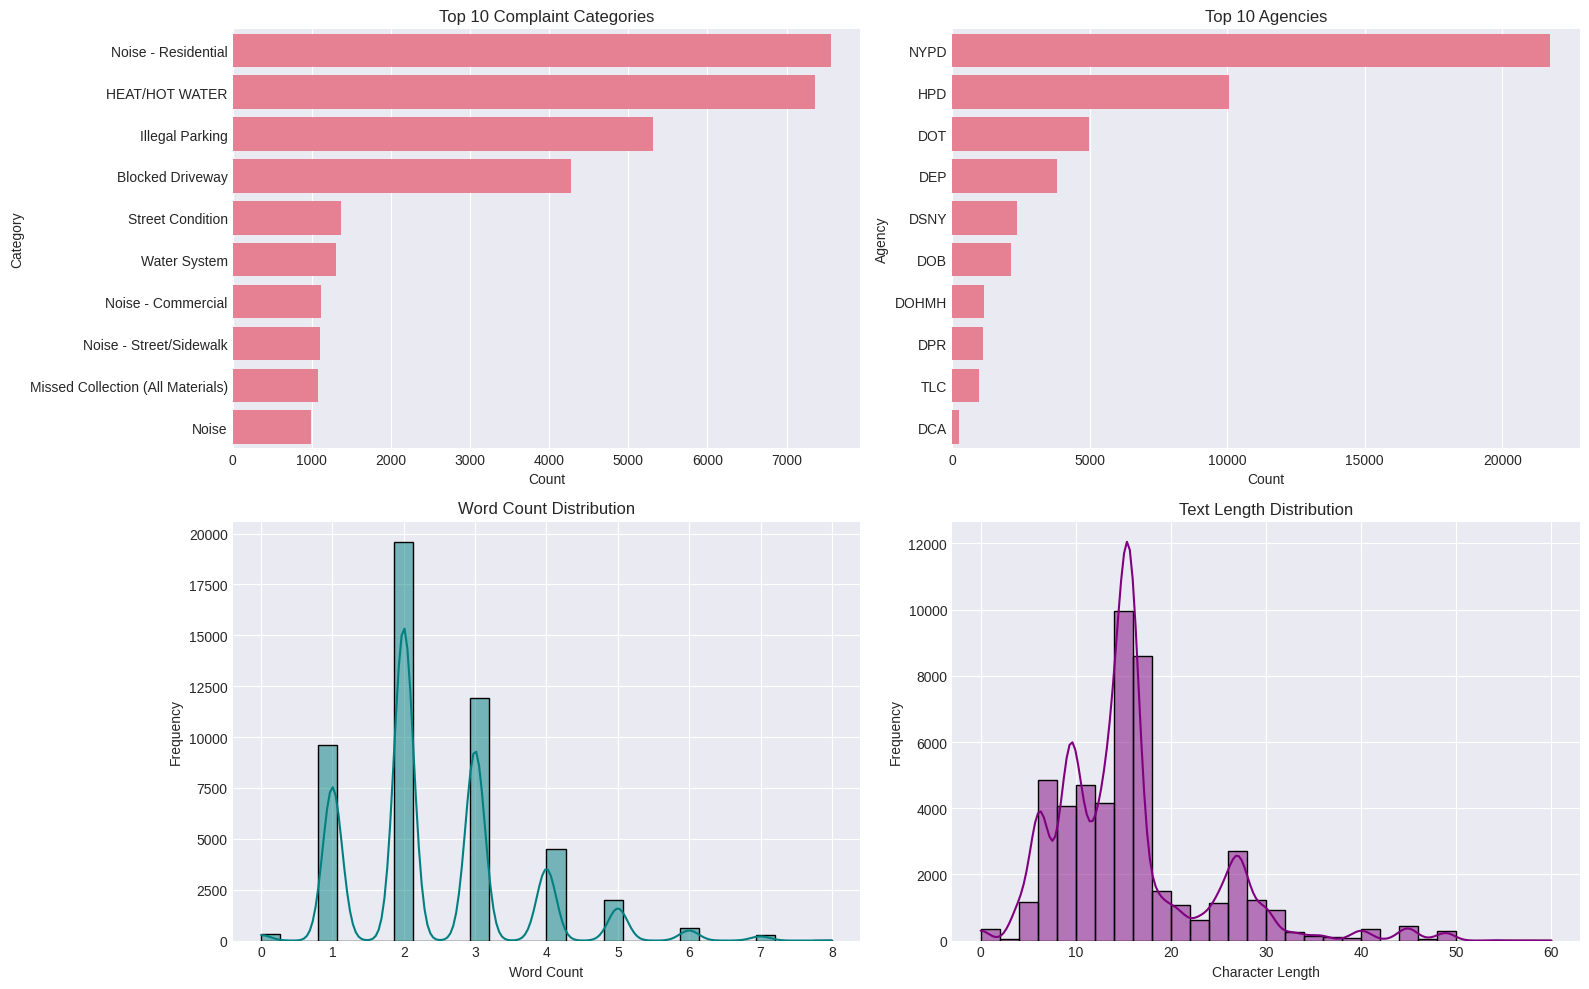

In [22]:
# Small visualizations for the cleaned NLP dataset

if 'text_cleaned' not in df.columns:
	df['text_cleaned'] = df['text'].astype(str)

if 'text_length' not in df.columns:
	df['text_length'] = df['text_cleaned'].str.len()

if 'word_count' not in df.columns:
	df['word_count'] = df['text_cleaned'].str.split().str.len()

top_categories_plot = df['category'].value_counts().head(10)
top_agencies_plot = df['agency'].value_counts().head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(
	x=top_categories_plot.values,
	y=top_categories_plot.index,
	ax=axes[0, 0]
)
axes[0, 0].set_title('Top 10 Complaint Categories')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Category')

sns.barplot(
	x=top_agencies_plot.values,
	y=top_agencies_plot.index,
	ax=axes[0, 1]
)
axes[0, 1].set_title('Top 10 Agencies')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Agency')

sns.histplot(df['word_count'], bins=30, kde=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Word Count Distribution')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df['text_length'], bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Text Length Distribution')
axes[1, 1].set_xlabel('Character Length')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()